In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned dataset from Task 1

df = pd.read_csv(r"C:\Users\Eucloid\Desktop\SWYNEX EDA\Clean Data\Netflix_Cleaned_Data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 250
Columns: 13


,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_minutes,duration_seasons
0,s72,Movie,Velvet Secret,Unknown,"Aamir Khan, Nawazuddin Siddiqui, Anya Taylor, ...",United Kingdom,2024-06-25,2024,TV-14,"Thrillers,Comedies",A young artist fights to save her neighborhood.,NaN,NaN
1,s239,Movie,The Midnight Empire,Anurag Kashyap,"Deepika Padukone, Lupita Nyongo",France,2015-07-09,2004,TV-MA,"Crime TV Shows, Dramas",,162.0,NaN
2,s228,TV Show,Broken City,Steven Lee,"Emma Stone, Ryan Gosling",India,2015-07-09,2006,R,"Comedies, Horror Movies",A documentary exploring life in a rapidly chan...,NaN,4.0
3,s57,Movie,Distant Promise,Anurag Kashyap,"Priyanka Chopra, Lupita Nyongo",France,2023-12-31,2023,G,"Thrillers, International Movies",A documentary exploring life in a rapidly chan...,131.0,NaN
4,s180,Movie,Distant Road,Unknown,"Rohit Sharma, Deepika Padukone, John Cho, Irrf...",Spain,2015-07-09,2007,R,"Action & Adventure,Comedies",An investigator uncovers a conspiracy in a sma...,450.0,NaN


In [37]:
# 1. BASIC DATASET INFORMATION

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (250, 13)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'listed_in', 'description', 'duration_minutes', 'duration_seasons']

Data Types:
show_id                 str
type                    str
title                   str
director                str
cast                    str
country                 str
date_added              str
release_year          int64
rating                  str
listed_in               str
description             str
duration_minutes    float64
duration_seasons    float64
dtype: object

Missing Values:
show_id               0
type                  0
title                 0
director              0
cast                  0
country               0
date_added            0
release_year          0
rating                0
listed_in             0
description           0
duration_minutes    124
duration_seasons    181
dtype: int64

Duplicate Rows: 0


In [38]:
# 2. STATISTICAL SUMMARY

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,250,236,s239,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,250,8,Movie,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,250,250,Velvet Secret,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,250,24,Unknown,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,250,197,Unknown,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,250,25,Germany,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,250,28,2015-07-09,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,250.0,NaN,NaN,NaN,1960.424,403.858096,-2005.0,2006.0,2013.0,2018.0,2024.0
rating,250,21,TV-14,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,250,108,"Crime TV Shows, Romantic Movies",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# 3. UNIQUE VALUES IN EACH COLUMN

for column in df.columns:
    print(f"\n{column}:")
    print("Unique values:", df[column].nunique())


show_id:
Unique values: 236

type:
Unique values: 8

title:
Unique values: 250

director:
Unique values: 24

cast:
Unique values: 197

country:
Unique values: 25

date_added:
Unique values: 28

release_year:
Unique values: 30

rating:
Unique values: 21

listed_in:
Unique values: 108

description:
Unique values: 9

duration_minutes:
Unique values: 71

duration_seasons:
Unique values: 7


Content Type Distribution:
type
Movie      126
TV Show     69
movie       15
MOVIE       13
 Movie      11
tv show      8
TV SHOW      5
TVShow       3
Name: count, dtype: int64


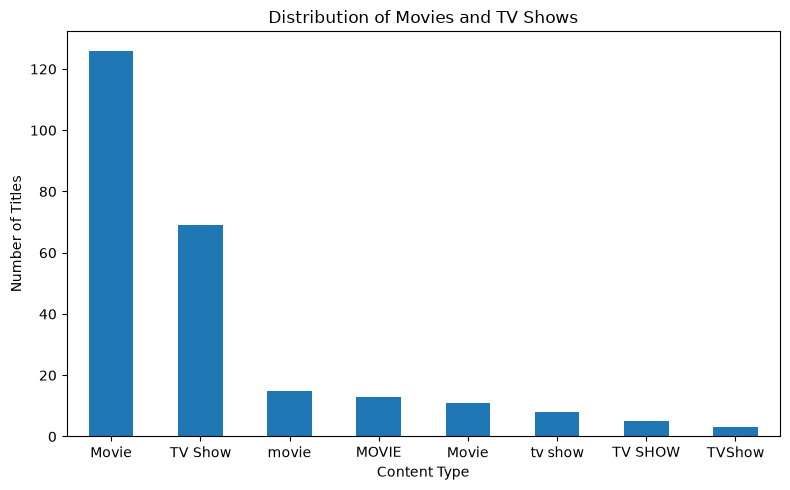

In [40]:
# 4. CONTENT TYPE ANALYSIS

type_counts = df["type"].value_counts()

print("Content Type Distribution:")
print(type_counts)

plt.figure(figsize=(8, 5))
type_counts.plot(kind="bar")

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 Countries by Number of Titles:
country
Germany           43
Japan             26
Australia         24
Canada            23
South Korea       21
Spain             20
France            17
India             10
UK                10
United Kingdom     9
Name: count, dtype: int64


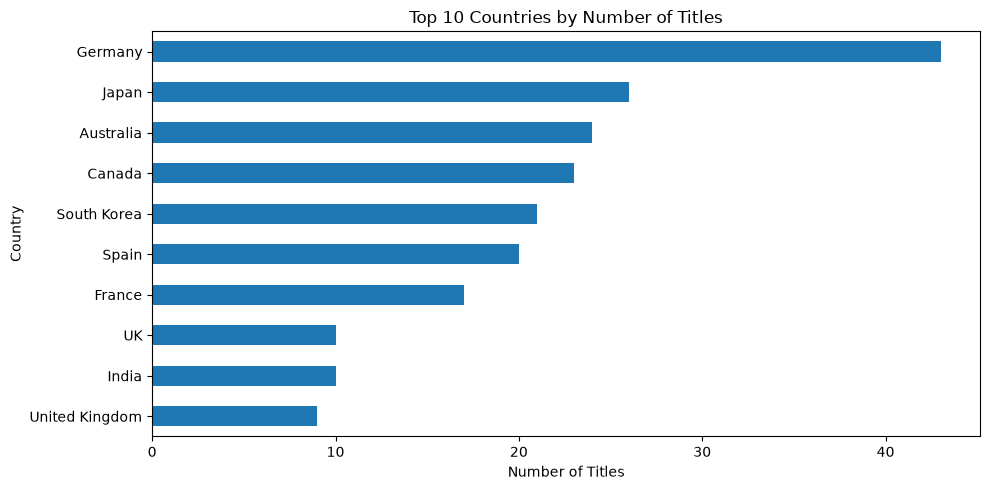

In [41]:
# 5. TOP 10 COUNTRIES

country_counts = df["country"].value_counts().head(10)

print("Top 10 Countries by Number of Titles:")
print(country_counts)

plt.figure(figsize=(10, 5))
country_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

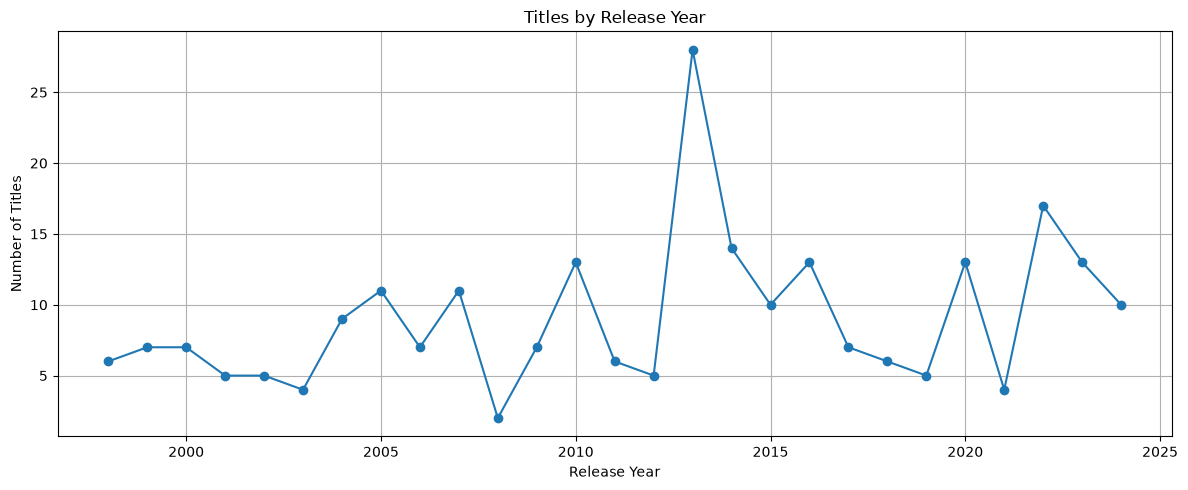

In [42]:
# 6. RELEASE YEAR TREND

valid_years = df[
    (df["release_year"] >= 1900) &
    (df["release_year"] <= 2025)
]

year_counts = valid_years["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
year_counts.plot(kind="line", marker="o")

plt.title("Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.show()

Top Content Ratings:
rating
TV-14    46
TV-PG    30
PG       30
R        26
G        25
PG-13    23
TV-MA    21
TV-Y7    18
g         6
tv14      5
Name: count, dtype: int64


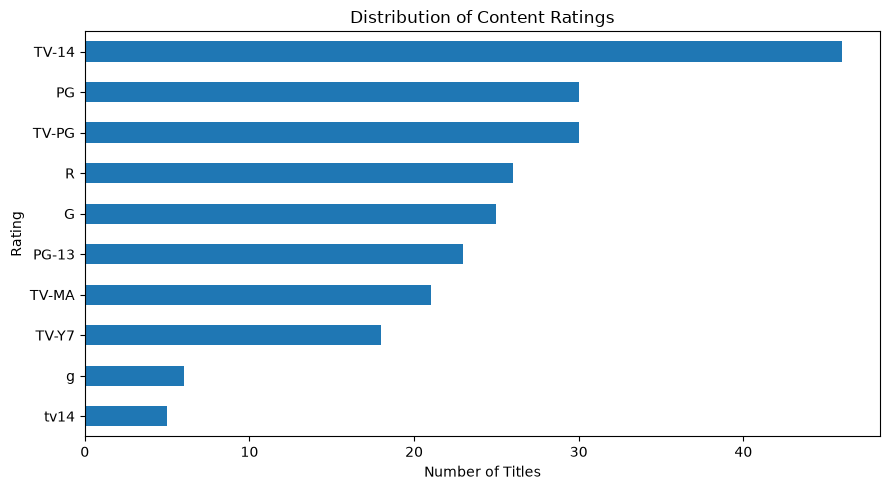

In [43]:
# 7. CONTENT RATING ANALYSIS

rating_counts = df["rating"].value_counts().head(10)

print("Top Content Ratings:")
print(rating_counts)

plt.figure(figsize=(9, 5))
rating_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

Average Movie Duration: 127.05 minutes
Minimum Movie Duration: 2.0 minutes
Maximum Movie Duration: 450.0 minutes


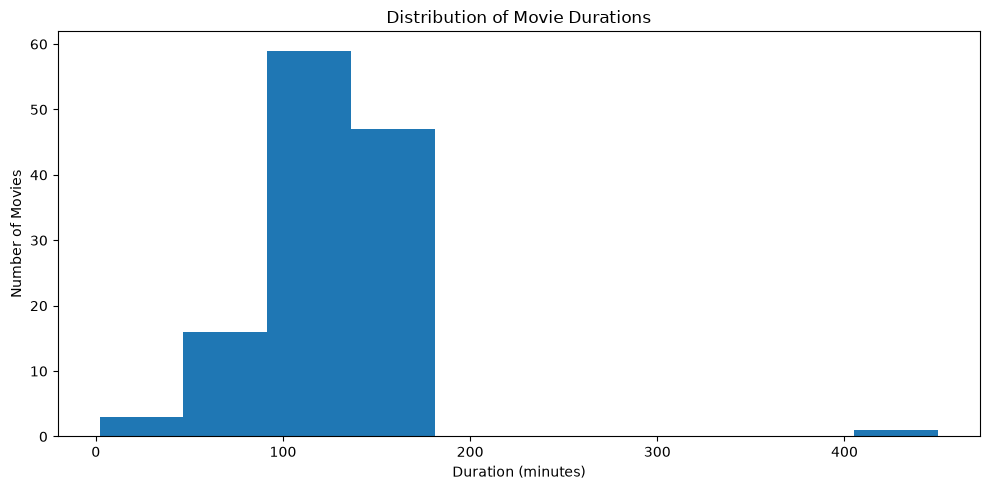

In [44]:
# 8. MOVIE DURATION ANALYSIS

movie_duration = df.loc[
    df["type"] == "Movie", "duration_minutes"
].dropna()

print("Average Movie Duration:", round(movie_duration.mean(), 2), "minutes")
print("Minimum Movie Duration:", movie_duration.min(), "minutes")
print("Maximum Movie Duration:", movie_duration.max(), "minutes")

plt.figure(figsize=(10, 5))
plt.hist(movie_duration, bins=10)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

Average TV Show Seasons: 6.84
Minimum Seasons: 1.0
Maximum Seasons: 110.0


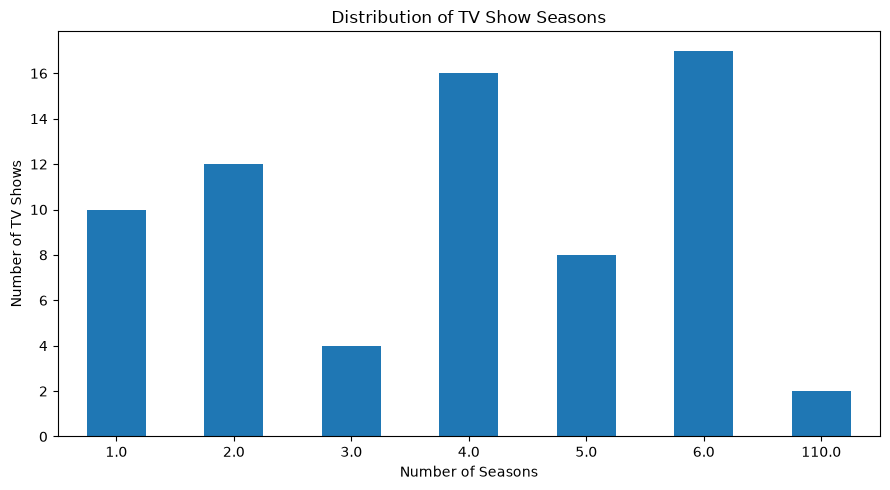

In [45]:
# 9. TV SHOW SEASON ANALYSIS

tv_seasons = df.loc[
    df["type"] == "TV Show", "duration_seasons"
].dropna()

print("Average TV Show Seasons:", round(tv_seasons.mean(), 2))
print("Minimum Seasons:", tv_seasons.min())
print("Maximum Seasons:", tv_seasons.max())

plt.figure(figsize=(9, 5))
tv_seasons.value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

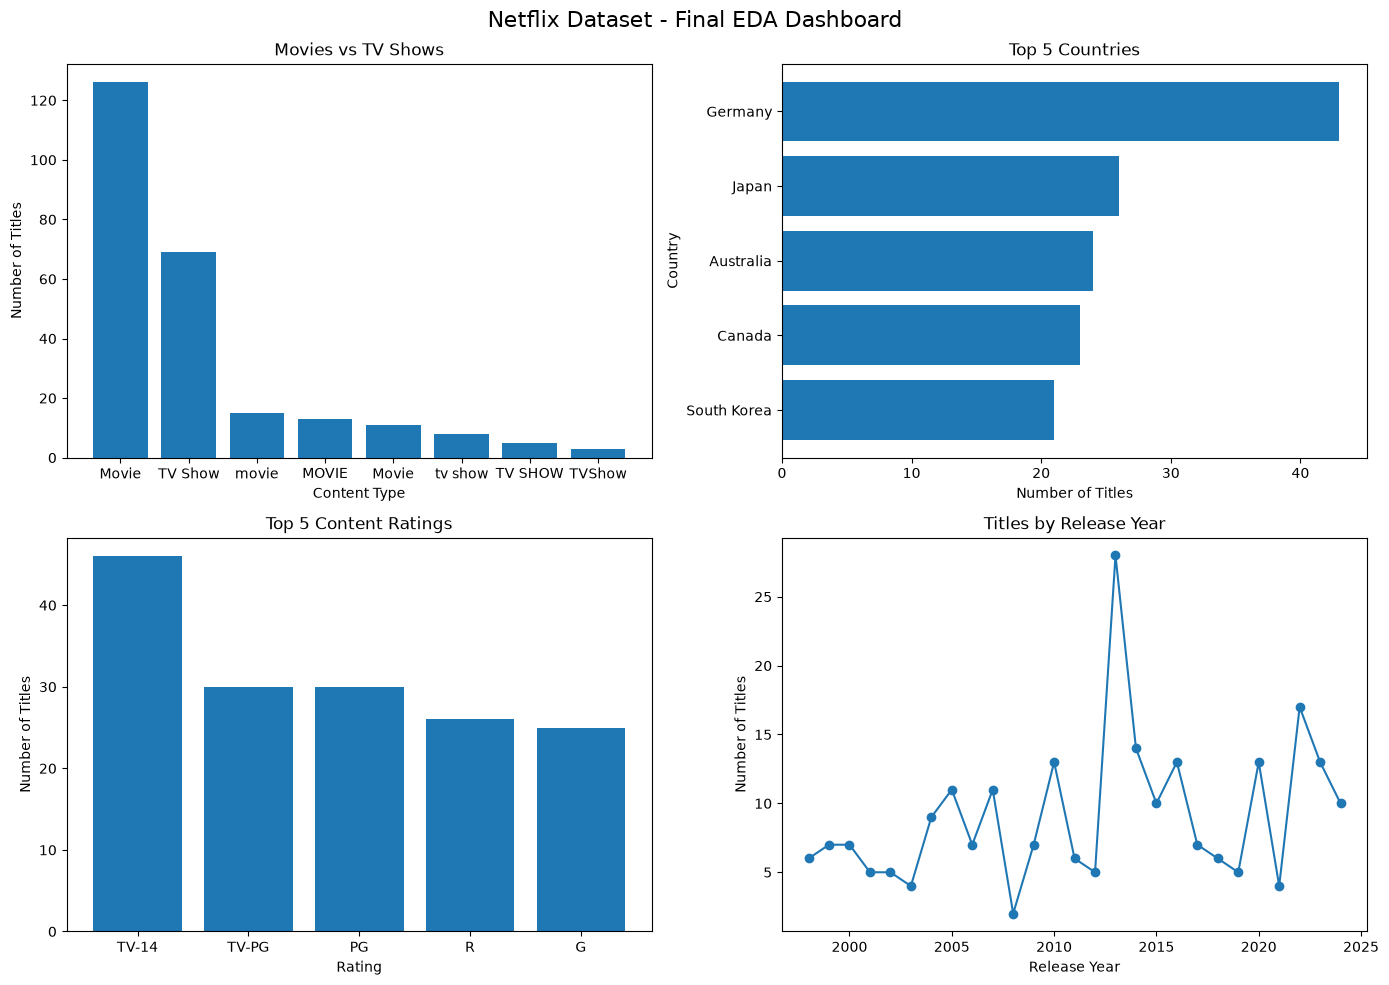

In [46]:
# FINAL VISUALIZATION / DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Movies vs TV Shows
type_counts = df["type"].value_counts()
axes[0, 0].bar(type_counts.index, type_counts.values)
axes[0, 0].set_title("Movies vs TV Shows")
axes[0, 0].set_xlabel("Content Type")
axes[0, 0].set_ylabel("Number of Titles")

# 2. Top 5 Countries
country_counts = df["country"].value_counts().head(5)
axes[0, 1].barh(country_counts.index[::-1], country_counts.values[::-1])
axes[0, 1].set_title("Top 5 Countries")
axes[0, 1].set_xlabel("Number of Titles")
axes[0, 1].set_ylabel("Country")

# 3. Top 5 Ratings
rating_counts = df["rating"].value_counts().head(5)
axes[1, 0].bar(rating_counts.index, rating_counts.values)
axes[1, 0].set_title("Top 5 Content Ratings")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Number of Titles")

# 4. Titles by Release Year
valid_years = df[
    (df["release_year"] >= 1900) &
    (df["release_year"] <= 2025)
]

year_counts = valid_years["release_year"].value_counts().sort_index()

axes[1, 1].plot(year_counts.index, year_counts.values, marker="o")
axes[1, 1].set_title("Titles by Release Year")
axes[1, 1].set_xlabel("Release Year")
axes[1, 1].set_ylabel("Number of Titles")

plt.suptitle("Netflix Dataset - Final EDA Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

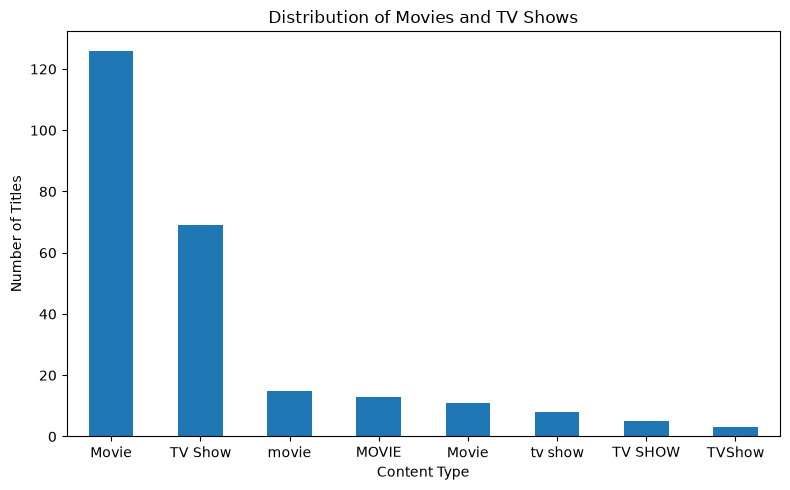

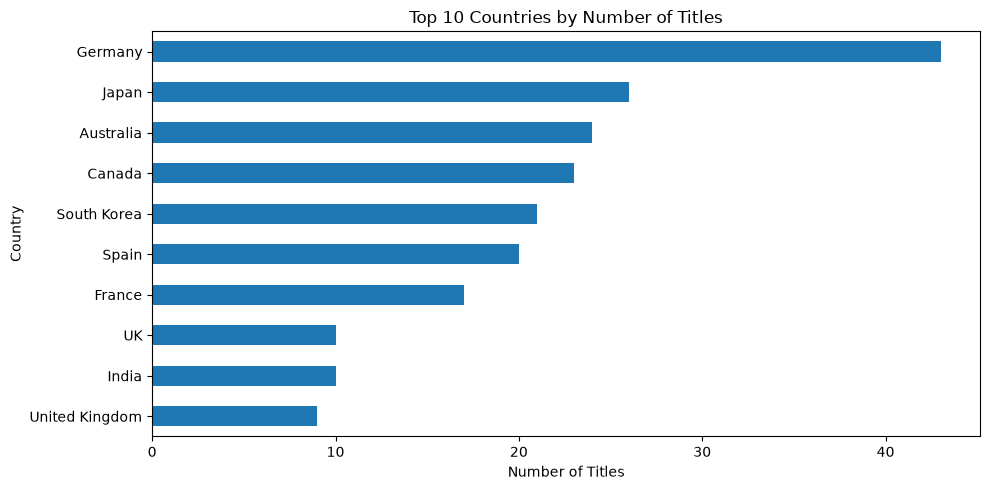

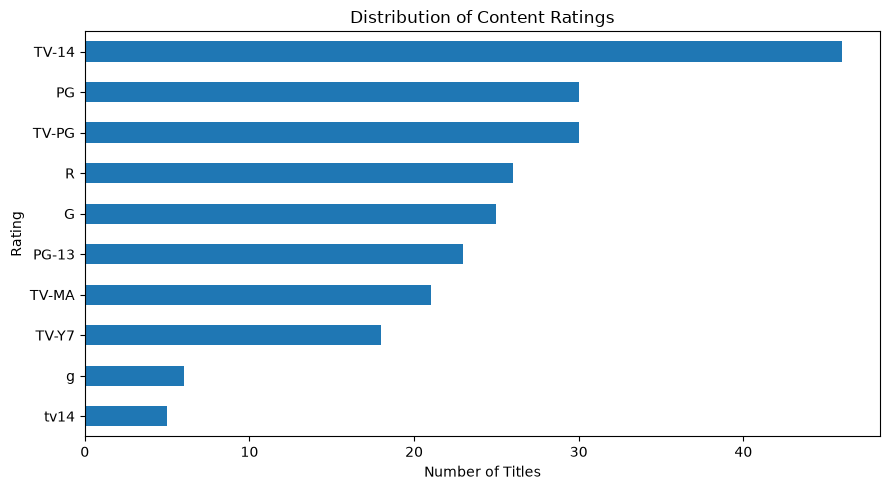

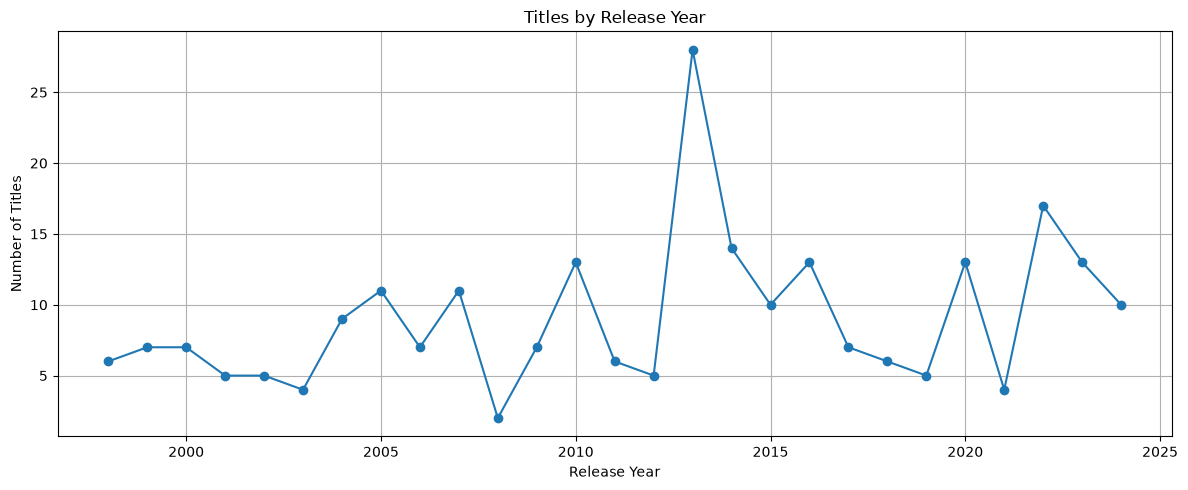

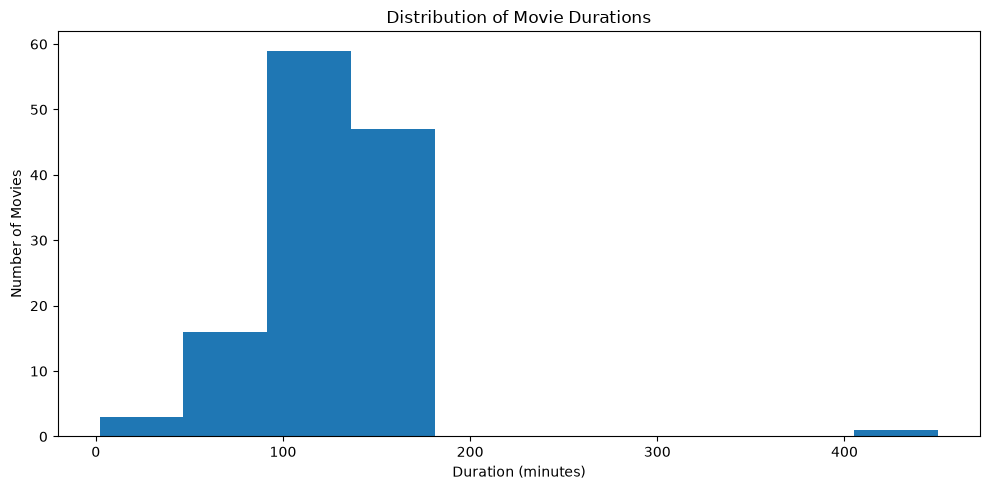

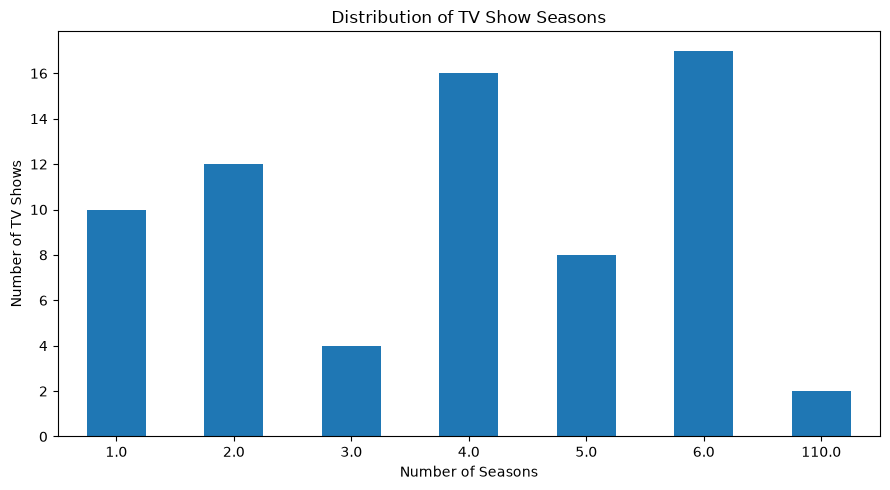

All EDA charts saved successfully in the Charts folder!


In [47]:
# SAVE ALL EDA CHARTS

import os

# Create Charts folder
os.makedirs("Charts", exist_ok=True)

# 1. Movies vs TV Shows
type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
type_counts.plot(kind="bar")
plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Charts/Movies_vs_TV_Shows.png", dpi=300, bbox_inches="tight")
plt.show()


# 2. Top 10 Countries
country_counts = df["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
country_counts.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("Charts/Top_10_Countries.png", dpi=300, bbox_inches="tight")
plt.show()


# 3. Content Ratings
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(9, 5))
rating_counts.sort_values().plot(kind="barh")
plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("Charts/Content_Ratings.png", dpi=300, bbox_inches="tight")
plt.show()


# 4. Release Year Trend
valid_years = df[
    (df["release_year"] >= 1900) &
    (df["release_year"] <= 2025)
]

year_counts = valid_years["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
year_counts.plot(kind="line", marker="o")
plt.title("Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.savefig("Charts/Release_Year_Trend.png", dpi=300, bbox_inches="tight")
plt.show()


# 5. Movie Duration
movie_duration = df.loc[
    df["type"] == "Movie", "duration_minutes"
].dropna()

plt.figure(figsize=(10, 5))
plt.hist(movie_duration, bins=10)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("Charts/Movie_Duration.png", dpi=300, bbox_inches="tight")
plt.show()


# 6. TV Show Seasons
tv_seasons = df.loc[
    df["type"] == "TV Show", "duration_seasons"
].dropna()

plt.figure(figsize=(9, 5))
tv_seasons.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Charts/TV_Show_Seasons.png", dpi=300, bbox_inches="tight")
plt.show()


print("All EDA charts saved successfully in the Charts folder!")

In [48]:
plt.savefig("Charts/Final_EDA_Dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

# 5. KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

### Insight 1: Movie vs TV Show Distribution
The dataset contains more Movies than TV Shows. Movies represent the majority of the available titles, indicating that the dataset is more focused on movie content.

### Insight 2: Movie Duration
Most movies have a duration between approximately 90 and 180 minutes. The distribution shows that movie durations are concentrated around the 100–150 minute range. A few unusually long movies, such as the 450-minute entry, appear as potential outliers.

### Insight 3: TV Show Seasons
Most TV Shows have between 1 and 6 seasons. The majority are concentrated around 4–6 seasons. The value of 110 seasons is an extreme outlier and should be investigated as a possible data-quality issue.

### Insight 4: Content Ratings
TV-14 is the most common content rating in the dataset. Other frequently occurring ratings include PG, TV-PG, R and G. This indicates that the dataset contains content suitable for a wide range of audiences, with TV-14 being particularly common.

### Insight 5: Release Year Trend
The number of titles varies considerably across release years. The dataset shows a noticeable peak around 2013, followed by fluctuations in the number of titles released in subsequent years.

### Additional Insight: Country Distribution
Germany has the highest number of titles among the countries shown in the Top 10 chart, followed by Japan and Australia. This indicates that the dataset contains substantial international content rather than being limited to one country.

In [49]:
# SAVE FINAL CLEANED DATASET

output_file = "Netflix_Cleaned_Data_Final.csv"

df.to_csv(output_file, index=False)

print("File saved successfully!")
print("File name:", output_file)

File saved successfully!
File name: Netflix_Cleaned_Data_Final.csv
